Logistic Regression:


Contributions:
1. https://www.ibm.com/think/topics/logistic-regression
2. https://www.analyticsvidhya.com/blog/2023/01/a-comprehensive-guide-to-ols-regression-part-1/

In [11]:
# Libraries:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from itertools import combinations
from sklearn.model_selection import BaseCrossValidator, ParameterGrid
from sklearn.metrics import (
    roc_auc_score, classification_report, accuracy_score,
    f1_score, recall_score, precision_score, average_precision_score,
    roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
)
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import os

In [12]:
# Data import and pre-processing:

os.chdir('C:/Users/p528552/OneDrive - South African Reserve Bank/Documents/1. MEng - Data Science/1. Project_2025/Data/factor_timing/data_input')

# Data import:
df_factor = pd.read_csv("labeled_relative_factor_returns.csv", parse_dates=['Date'])
df_factor = df_factor[['Date','Value_vs_Quality_trend']]    
df_factor = df_factor.set_index('Date')

df = pd.read_csv("lagged_data.csv", parse_dates=['Date'])
df = df.set_index('Date')


data = pd.concat([df,df_factor], axis=1, join='inner')
data = data.dropna()

print(data)

            VolTermStructPC1  VolTermStructPC2  MichgnConcIndx  \
Date                                                             
2008-06-30         43.764525          6.157399            59.8   
2008-07-07         47.865713          4.654912            59.8   
2008-07-14         44.722107          5.007951            59.8   
2008-07-21         46.645075          4.146473            59.8   
2008-07-28         47.943107          3.404113            56.4   
...                      ...               ...             ...   
2024-01-01         32.753330         -9.716542            61.3   
2024-01-08         31.765017         -9.542882            61.3   
2024-01-15         31.849078         -9.517372            61.3   
2024-01-22         32.957527         -9.821722            61.3   
2024-01-29         31.661633         -9.617528            69.7   

            RandPPP_Factor_Inst_TS_ST  BCMPEBLS.Index  PPP.ZA.Index_QS  \
Date                                                               

In [13]:
class LogisticRegression:
    def __init__(self, learning_rate=0.01, num_iterations=1000, tol=1e-4,
                 regularization="none", lambda_reg=0.0):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.tol = tol
        self.regularization = regularization.lower()
        self.lambda_reg = lambda_reg
        self.beta = None
        self.cost_history = []
    
    def sigmoid(self, z):
        return np.where(z >= 0,
                        1 / (1 + np.exp(-z)),
                        np.exp(z) / (1 + np.exp(z)))
    
    def cost_function(self, X, y, beta):
        m = len(y)
        h = self.sigmoid(X.dot(beta))
        h = np.clip(h, 1e-10, 1 - 1e-10)

        # Base logistic loss
        cost = (-1/m) * np.sum(y * np.log(h) + (1-y) * np.log(1-h))

        # Add regularization penalty (exclude bias term beta[0])
        if self.regularization == "l2":
            cost += (self.lambda_reg / (2 * m)) * np.sum(beta[1:] ** 2)
        elif self.regularization == "l1":
            cost += (self.lambda_reg / m) * np.sum(np.abs(beta[1:]))

        return cost
    
    def compute_gradient(self, X, y, beta):
        """Handles L1 and L2 penalties."""
        m = len(y)
        h = self.sigmoid(X.dot(beta))
        gradient = (1/m) * X.T.dot(h - y)

        # Regularize beta[1:], not the bias
        if self.regularization == "l2":
            gradient[1:] += (self.lambda_reg / m) * beta[1:]
        elif self.regularization == "l1":
            gradient[1:] += (self.lambda_reg / m) * np.sign(beta[1:])

        return gradient
    
    def gradient_descent(self, X, y, beta):
        m = len(y)
        for i in range(self.num_iterations):
            gradient = self.compute_gradient(X, y, beta)
            new_beta = beta - self.learning_rate * gradient
            
            change = np.linalg.norm(new_beta - beta)
            if i > 500 and change < self.tol:
                print(f"Converged after {i} iterations (Δβ={change:.2e})")
                break
                
            beta = new_beta
            self.cost_history.append(self.cost_function(X, y, beta))

        return beta
    
    def fit(self, X, y):
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        self.beta = np.zeros(X_b.shape[1])
        self.beta = self.gradient_descent(X_b, y, self.beta)
    
    def predict_proba(self, X):
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        return self.sigmoid(X_b.dot(self.beta))
    
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


In [14]:

# ============================================================
# Combinatorial Purged Cross-Validation (CPCV)
# ============================================================
CV_SPLITS = 5
CV_TEST_SPLITS = 1
PURGE_GAP = 24
FINAL_TEST_POINTS = 156   # 3 years of unseen data

# ===========================================================
# CPCV Splitter
# ===========================================================
class CombinatorialPurgedCV(BaseCrossValidator):
    """Purged Combinatorial Cross-Validation (De Prado style)."""
    def __init__(self, n_splits=CV_SPLITS, n_test_splits=CV_TEST_SPLITS, purge_gap=PURGE_GAP):
        self.n_splits = n_splits
        self.n_test_splits = n_test_splits
        self.purge_gap = purge_gap
    
    def split(self, X, y=None, groups=None): 
        n_samples = len(X)
        fold_size = n_samples // self.n_splits
        indices = np.arange(n_samples)

        fold_boundaries = [(i * fold_size, (i + 1) * fold_size) for i in range(self.n_splits)]
        fold_boundaries[-1] = (fold_boundaries[-1][0], n_samples)

        for test_folds in combinations(range(self.n_splits), self.n_test_splits):
            test_mask = np.zeros(n_samples, dtype=bool)
            for f in test_folds:
                s, e = fold_boundaries[f]
                test_mask[s:e] = True

            train_mask = ~test_mask
            for f in test_folds:
                s, e = fold_boundaries[f]
                train_mask[max(0, s - self.purge_gap): s] = False
                train_mask[e: min(n_samples, e + self.purge_gap)] = False

            yield indices[train_mask], indices[test_mask]

    def get_n_splits(self, X=None, y=None, groups=None):
        from math import comb
        return comb(self.n_splits, self.n_test_splits)




In [15]:
# ===========================================================
# CPCV Hyperparameter Tuning
# ===========================================================
def tune_hyperparameters(X, y):
    cv = CombinatorialPurgedCV()
    param_grid = {
        "learning_rate": [0.01, 0.05, 0.1],
        "num_iterations": [500, 1000, 2000],
        "tol": [1e-3, 1e-4, 1e-5],
        "regularization": ["none", "l1", "l2"],
        "lambda_reg": [0.0, 0.01, 0.1, 1.0],
        #"base_score":[0.5,0.6,0.7]
    }

    best_score, best_params = -np.inf, None
    results = []

    print(f"Testing {len(ParameterGrid(param_grid))} parameter combinations...")
    for params in ParameterGrid(param_grid):
        fold_scores = []
        for train_idx, test_idx in cv.split(X, y):
            model = LogisticRegression(**params)
            model.fit(X[train_idx], y[train_idx])
            y_pred = model.predict(X[test_idx])
            score = roc_auc_score(y[test_idx], y_pred)
            fold_scores.append(score)

        mean_score = np.mean(fold_scores)
        results.append((params, mean_score))
        if mean_score > best_score:
            best_score, best_params = mean_score, params
            print(f"New best params: {best_params} (AUC: {best_score:.3f})")

    results.sort(key=lambda x: x[1], reverse=True)
    print("\n=== Top 5 Parameter Combinations ===")
    for params, score in results[:5]:
        print(f"Score: {score:.3f} | Params: {params}")

    return best_params

In [16]:
# ===========================================================
# Walk-Forward Validation
# ===========================================================
"""
def walk_forward_validation(X, y, n_test, base_params, retune_every=None):
    actuals, predictions, probabilities = [], [], []
    current_params = base_params.copy()

    print(f"\nRunning Walk-Forward Validation on {n_test} test samples...")
    for i in tqdm(range(n_test)):
        train_size = len(X) - n_test + i
        if train_size <= 0:
            continue

        X_train, X_test = X[:train_size], X[train_size:train_size+1]
        y_train, y_test = y[:train_size], y[train_size:train_size+1]

        if retune_every is not None and i > 0 and i % retune_every == 0:
            print(f"\n--- Retuning at step {i}, train_size={train_size} ---")
            current_params = tune_hyperparameters(X_train, y_train)

        model = LogisticRegression(**current_params)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)

        predictions.append(y_pred[0])
        actuals.append(y_test[0])
        probabilities.append(y_prob[0])

    print("\n=== Final Evaluation Results ===")
    print(classification_report(actuals, predictions))

    return np.array(actuals), np.array(predictions), np.array(probabilities)
    
"""

'\ndef walk_forward_validation(X, y, n_test, base_params, retune_every=None):\n    actuals, predictions, probabilities = [], [], []\n    current_params = base_params.copy()\n\n    print(f"\nRunning Walk-Forward Validation on {n_test} test samples...")\n    for i in tqdm(range(n_test)):\n        train_size = len(X) - n_test + i\n        if train_size <= 0:\n            continue\n\n        X_train, X_test = X[:train_size], X[train_size:train_size+1]\n        y_train, y_test = y[:train_size], y[train_size:train_size+1]\n\n        if retune_every is not None and i > 0 and i % retune_every == 0:\n            print(f"\n--- Retuning at step {i}, train_size={train_size} ---")\n            current_params = tune_hyperparameters(X_train, y_train)\n\n        model = LogisticRegression(**current_params)\n        model.fit(X_train, y_train)\n\n        y_pred = model.predict(X_test)\n        y_prob = model.predict_proba(X_test)\n\n        predictions.append(y_pred[0])\n        actuals.append(y_test[0

In [ ]:
import hashlib

def window_signature(X):
    """
    Create a stable, compact signature for a rolling window
    based on its mean and std across features.
    """
    stats = np.concatenate([X.mean(axis=0), X.std(axis=0)])
    stats_bytes = stats.tobytes()
    return hashlib.sha1(stats_bytes).hexdigest()

In [17]:
def walk_forward_validation(
    X, y, n_test, base_params,
    retune_every=52, lookback=360
):
    actuals, predictions, probabilities = [], [], []
    current_params = base_params.copy()

    hyperparam_cache = {}  # signature -> best_param_set

    print(f"\nRunning Rolling-Window WFV with Hyperparameter Caching...")
    print(f"Lookback window = {lookback} samples")

    for i in tqdm(range(n_test)):
        train_size = len(X) - n_test + i
        if train_size <= 0:
            continue

        # === Rolling window ===
        start = max(0, train_size - lookback)
        X_train = X[start:train_size]
        y_train = y[start:train_size]
        X_test  = X[train_size:train_size+1]
        y_test  = y[train_size:train_size+1]

        # === Adaptive tuning with caching ===
        if retune_every and i > 0 and i % retune_every == 0:

            # create stable signature of training window
            sig = window_signature(X_train)

            if sig in hyperparam_cache:
                print(f"\nReusing cached params at step {i}")
                current_params = hyperparam_cache[sig]

            else:
                print(f"\n--- Retuning at step {i} ---")
                current_params = tune_hyperparameters(X_train, y_train)

                hyperparam_cache[sig] = current_params

        # Train model
        model = LogisticRegression(**current_params)
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)

        predictions.append(y_pred[0])
        actuals.append(y_test[0])
        probabilities.append(y_prob[0])

    print("\n=== Final Evaluation Results ===")
    print(classification_report(actuals, predictions))
    return (
        np.array(actuals),
        np.array(predictions),
        np.array(probabilities)
    )


In [19]:
# ===========================================================
# Results graph
# ===========================================================

def display_walkforward_results(y_true, y_pred, y_proba=None):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)

    print("Walk-forward Performance:")
    print(f"Accuracy : {acc:.3f}")
    print(f"F1 Score : {f1:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"Precision: {prec:.3f}")

    if y_proba is not None:
        auc = roc_auc_score(y_true, y_proba)
        pr_auc = average_precision_score(y_true, y_proba)
        print(f"ROC AUC  : {auc:.3f}")
        print(f"PR  AUC  : {pr_auc:.3f}")

    # Graphs:
    plt.figure(figsize=(12,5))
    plt.plot(y_true, label="True", marker="o")
    plt.plot(y_pred, label="Predicted", marker="x")
    plt.title("Walk-forward Predictions vs True Values")
    plt.legend()
    plt.show()

    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        precs, recs, _ = precision_recall_curve(y_true, y_proba)
        plt.figure(figsize=(6,6))
        plt.plot(fpr, tpr, label=f"ROC (AUC={auc:.3f})")
        plt.plot([0,1],[0,1],'--',color='gray'); plt.legend(); plt.show()
        plt.figure(figsize=(6,6))
        plt.plot(recs, precs, label=f"PR (AP={pr_auc:.3f})", color="purple")
        plt.legend(); plt.show()

        cm = confusion_matrix(y_true, y_pred)
        ConfusionMatrixDisplay(cm).plot(cmap="Blues")
        plt.title("Confusion Matrix")
        plt.show()


In [20]:
"""
def main():
    # Data prep:
    X = data.iloc[:, :-1].values
    y = data.iloc[:, -1].values
    feature_names = data.columns[:-1].tolist()

    # Replace NaN/inf values
    X = np.nan_to_num(X, nan=np.nan, posinf=1e10, neginf=-1e10)

    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # === PHASE 1: HYPERPARAMETER TUNING ===
    print("=== PHASE 1: HYPERPARAMETER TUNING ===")
    best_params = tune_hyperparameters(X_scaled, y)

    # === PHASE 2: FINAL EVALUATION ===
    print("\n=== PHASE 2: FINAL EVALUATION ===")
    

    # --- Fixed parameters (no retuning) ---
    actuals_fixed, preds_fixed, probs_fixed = walk_forward_validation(
        X_scaled, y, n_test=FINAL_TEST_POINTS, base_params=best_params, retune_every=None
    )

    # --- Adaptive parameters (re-tune every N steps) ---
    actuals_adapt, preds_adapt, probs_adapt = walk_forward_validation(
        X_scaled, y, n_test=FINAL_TEST_POINTS, base_params=best_params, retune_every=52
    )

    # === PHASE 3: PERFORMANCE & PLOTS ===
    
    print("\n=== FIXED PARAMS RESULTS ===")
    display_walkforward_results(actuals_fixed, preds_fixed, probs_fixed)

    print("\n=== ADAPTIVE PARAMS RESULTS ===")
    display_walkforward_results(actuals_adapt, preds_adapt, probs_adapt)

    # Return all results for downstream use
    return {
        "best_params": best_params,
        "feature_names": feature_names,
        "fixed": (actuals_fixed, preds_fixed, probs_fixed),
        "adaptive": (actuals_adapt, preds_adapt, probs_adapt),
    }


# === Execute pipeline ===
if __name__ == "__main__":
    results = main()
"""

'\ndef main():\n    # Data prep:\n    X = data.iloc[:, :-1].values\n    y = data.iloc[:, -1].values\n    feature_names = data.columns[:-1].tolist()\n\n    # Replace NaN/inf values\n    X = np.nan_to_num(X, nan=np.nan, posinf=1e10, neginf=-1e10)\n\n    # Standardize features\n    scaler = StandardScaler()\n    X_scaled = scaler.fit_transform(X)\n\n    # === PHASE 1: HYPERPARAMETER TUNING ===\n    print("=== PHASE 1: HYPERPARAMETER TUNING ===")\n    best_params = tune_hyperparameters(X_scaled, y)\n\n    # === PHASE 2: FINAL EVALUATION ===\n    print("\n=== PHASE 2: FINAL EVALUATION ===")\n    \n\n    # --- Fixed parameters (no retuning) ---\n    actuals_fixed, preds_fixed, probs_fixed = walk_forward_validation(\n        X_scaled, y, n_test=FINAL_TEST_POINTS, base_params=best_params, retune_every=None\n    )\n\n    # --- Adaptive parameters (re-tune every N steps) ---\n    actuals_adapt, preds_adapt, probs_adapt = walk_forward_validation(\n        X_scaled, y, n_test=FINAL_TEST_POINTS, ba

=== PHASE 1: HYPERPARAMETER TUNING ===
Testing 324 parameter combinations...
New best params: {'lambda_reg': 0.0, 'learning_rate': 0.01, 'num_iterations': 500, 'regularization': 'none', 'tol': 0.001} (AUC: 0.522)
Converged after 501 iterations (Δβ=6.74e-04)
Converged after 501 iterations (Δβ=6.78e-04)
Converged after 501 iterations (Δβ=5.62e-04)
Converged after 501 iterations (Δβ=5.66e-04)
Converged after 501 iterations (Δβ=5.34e-04)
New best params: {'lambda_reg': 0.0, 'learning_rate': 0.01, 'num_iterations': 1000, 'regularization': 'none', 'tol': 0.0001} (AUC: 0.526)
Converged after 501 iterations (Δβ=6.74e-04)
Converged after 501 iterations (Δβ=6.78e-04)
Converged after 501 iterations (Δβ=5.62e-04)
Converged after 501 iterations (Δβ=5.66e-04)
Converged after 501 iterations (Δβ=5.34e-04)
Converged after 501 iterations (Δβ=6.74e-04)
Converged after 501 iterations (Δβ=6.78e-04)
Converged after 501 iterations (Δβ=5.62e-04)
Converged after 501 iterations (Δβ=5.66e-04)
Converged after 501

 33%|███▎      | 52/156 [00:05<00:14,  7.24it/s]


--- Retuning at step 52 ---
Testing 324 parameter combinations...
New best params: {'lambda_reg': 0.0, 'learning_rate': 0.01, 'num_iterations': 500, 'regularization': 'none', 'tol': 0.001} (AUC: 0.511)
Converged after 501 iterations (Δβ=7.82e-04)
Converged after 501 iterations (Δβ=8.52e-04)
Converged after 501 iterations (Δβ=9.26e-04)
Converged after 501 iterations (Δβ=7.73e-04)
Converged after 501 iterations (Δβ=7.54e-04)
New best params: {'lambda_reg': 0.0, 'learning_rate': 0.01, 'num_iterations': 1000, 'regularization': 'none', 'tol': 0.0001} (AUC: 0.521)
Converged after 501 iterations (Δβ=7.82e-04)
Converged after 501 iterations (Δβ=8.52e-04)
Converged after 501 iterations (Δβ=9.26e-04)
Converged after 501 iterations (Δβ=7.73e-04)
Converged after 501 iterations (Δβ=7.54e-04)
Converged after 501 iterations (Δβ=7.82e-04)
Converged after 501 iterations (Δβ=8.52e-04)
Converged after 501 iterations (Δβ=9.26e-04)
Converged after 501 iterations (Δβ=7.73e-04)
Converged after 501 iteration

 34%|███▍      | 53/156 [02:37<1:12:59, 42.52s/it]


=== Top 5 Parameter Combinations ===
Score: 0.555 | Params: {'lambda_reg': 0.01, 'learning_rate': 0.05, 'num_iterations': 2000, 'regularization': 'l1', 'tol': 0.0001}
Score: 0.555 | Params: {'lambda_reg': 0.01, 'learning_rate': 0.05, 'num_iterations': 2000, 'regularization': 'l1', 'tol': 1e-05}
Score: 0.555 | Params: {'lambda_reg': 0.01, 'learning_rate': 0.1, 'num_iterations': 1000, 'regularization': 'l1', 'tol': 0.001}
Score: 0.555 | Params: {'lambda_reg': 0.01, 'learning_rate': 0.1, 'num_iterations': 1000, 'regularization': 'l1', 'tol': 0.0001}
Score: 0.555 | Params: {'lambda_reg': 0.01, 'learning_rate': 0.1, 'num_iterations': 1000, 'regularization': 'l1', 'tol': 1e-05}


...

Converged after 1454 iterations (Δβ=1.00e-03)
Converged after 1430 iterations (Δβ=1.00e-03)


 99%|█████████▉| 155/156 [05:33<00:00,  6.71it/s]

Converged after 1372 iterations (Δβ=1.00e-03)
Converged after 1362 iterations (Δβ=1.00e-03)


100%|██████████| 156/156 [05:33<00:00,  2.14s/it]


Converged after 1363 iterations (Δβ=1.00e-03)

=== Final Evaluation Results ===
              precision    recall  f1-score   support

         0.0       0.60      0.51      0.55        73
         1.0       0.62      0.70      0.66        83

    accuracy                           0.61       156
   macro avg       0.61      0.60      0.60       156
weighted avg       0.61      0.61      0.61       156

Walk-forward Performance:
Accuracy : 0.609
F1 Score : 0.655
Recall   : 0.699
Precision: 0.617
ROC AUC  : 0.647
PR  AUC  : 0.665


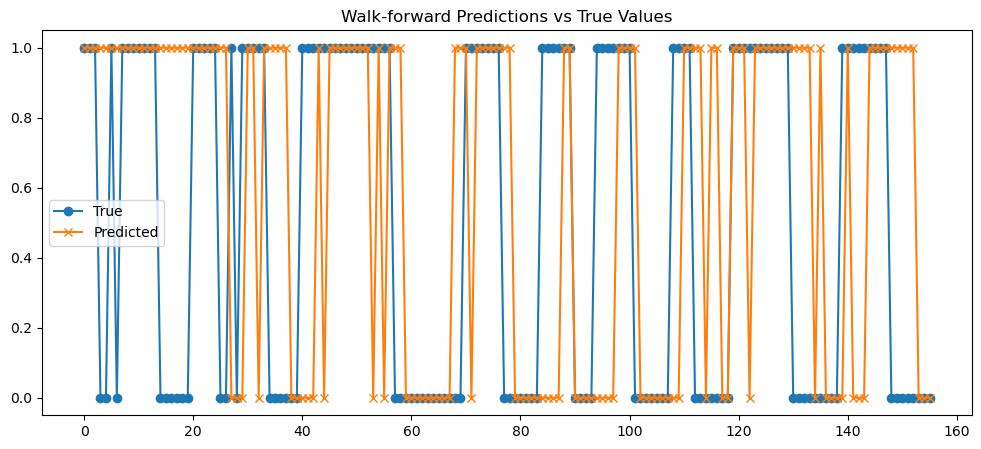

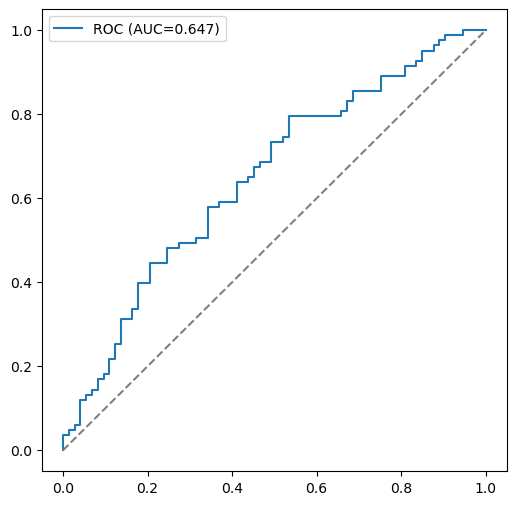

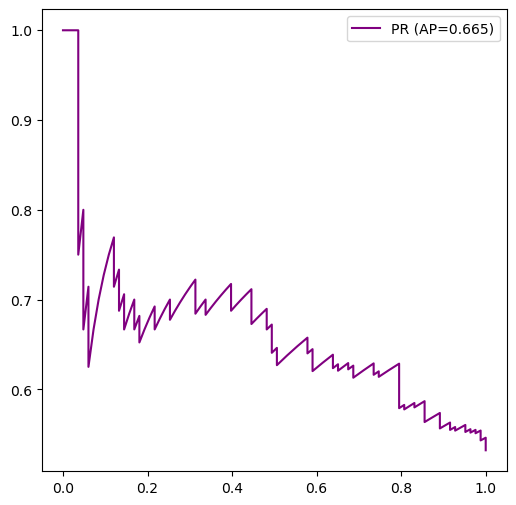

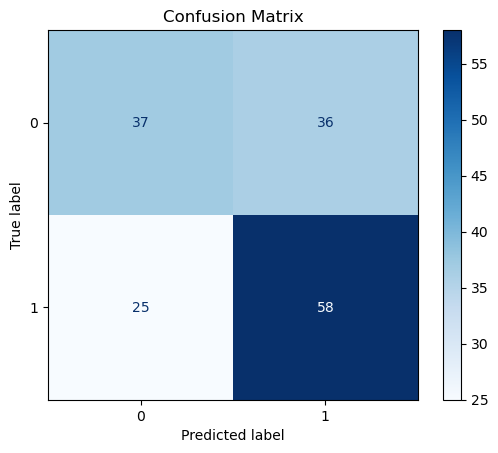

In [21]:
def main():
    # Data prep:
    X = data.iloc[:, :-1].values
    y = data.iloc[:, -1].values
    feature_names = data.columns[:-1].tolist()

    # Recover NaNs + scale
    X = np.nan_to_num(X, nan=np.nan, posinf=1e10, neginf=-1e10)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # === PHASE 1: HYPERPARAMETER TUNING (initial) ===
    print("=== PHASE 1: HYPERPARAMETER TUNING ===")
    best_params = tune_hyperparameters(X_scaled, y)

    # === PHASE 2: ADAPTIVE WALK-FORWARD ONLY ===
    print("\n=== PHASE 2: ADAPTIVE WALK-FORWARD (ONLY) ===")
    actuals, preds, probs = walk_forward_validation(
        X_scaled, y,
        n_test=FINAL_TEST_POINTS,
        base_params=best_params,
        retune_every=52     # ⬅️  Only adaptive mode
    )

    # === PHASE 3: RESULTS ===
    display_walkforward_results(actuals, preds, probs)

    return {
        "best_params": best_params,
        "feature_names": feature_names,
        "adaptive": (actuals, preds, probs),
    }


if __name__ == "__main__":
    results = main()


In [25]:

actuals = results["adaptive"][0]
preds   = results["adaptive"][1]
probs   = results["adaptive"][2]


df_probs = pd.DataFrame({
    "Date": data.index[-len(probs):],
    "actual": actuals,
    "prediction": preds,
    "probability": probs
}).set_index("Date")


In [26]:
df_probs.to_csv('log_value_quality_probs.csv',index=True)


=== Coefficient Magnitude Importance ===
GlobalPropertyVol12                     0.201477
TOP40.Index.Price.to.Ebitda_Diff        0.192545
USDZAR_EntDyn                           0.150756
SA_NB_Slope                             0.147566
MichgnConcIndx                          0.145394
GlobalBondVol6                          0.127497
GLD_RollSD                              0.123663
zrel_momentum_vs_quality_12             0.121351
VolTermStructPC1                        0.118171
GLD_StructBreak                         0.116287
TOP40.Index.Price.to.Book.Ratio_Diff    0.102783
US_RB_Curvature                         0.101941
RandPPP_Factor_Inst_TS_ST               0.095548
relvol_momentum_vs_quality_12           0.091985
corr_value_quality_12                   0.087886
volratio_momentum_quality_12            0.084790
GlobalEquityTS                          0.081155
zrel_value_vs_quality_12                0.073533
GLD_RollSkew                            0.056874
JALSH_Fundamental_PC1      

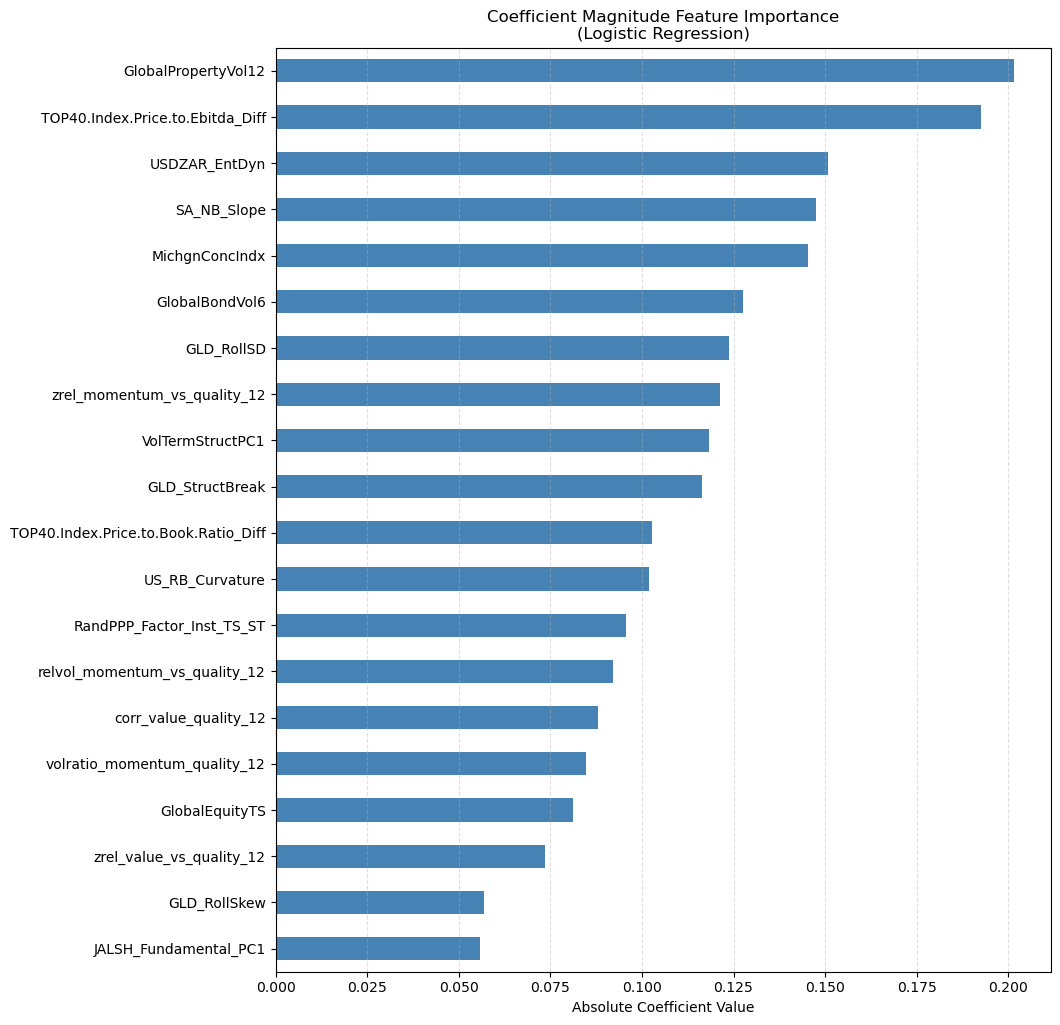


=== Global SHAP Importance (Mean |Contribution|) ===
GlobalPropertyVol12                     0.170589
TOP40.Index.Price.to.Ebitda_Diff        0.141378
USDZAR_EntDyn                           0.136275
MichgnConcIndx                          0.122365
zrel_momentum_vs_quality_12             0.097925
GlobalBondVol6                          0.097797
VolTermStructPC1                        0.094567
SA_NB_Slope                             0.093778
GLD_RollSD                              0.092670
GLD_StructBreak                         0.089897
US_RB_Curvature                         0.085365
RandPPP_Factor_Inst_TS_ST               0.081575
TOP40.Index.Price.to.Book.Ratio_Diff    0.074768
corr_value_quality_12                   0.070856
volratio_momentum_quality_12            0.067622
GlobalEquityTS                          0.067386
relvol_momentum_vs_quality_12           0.065192
zrel_value_vs_quality_12                0.060032
JALSH_Fundamental_PC1                   0.054047
GLD_RollSkew   

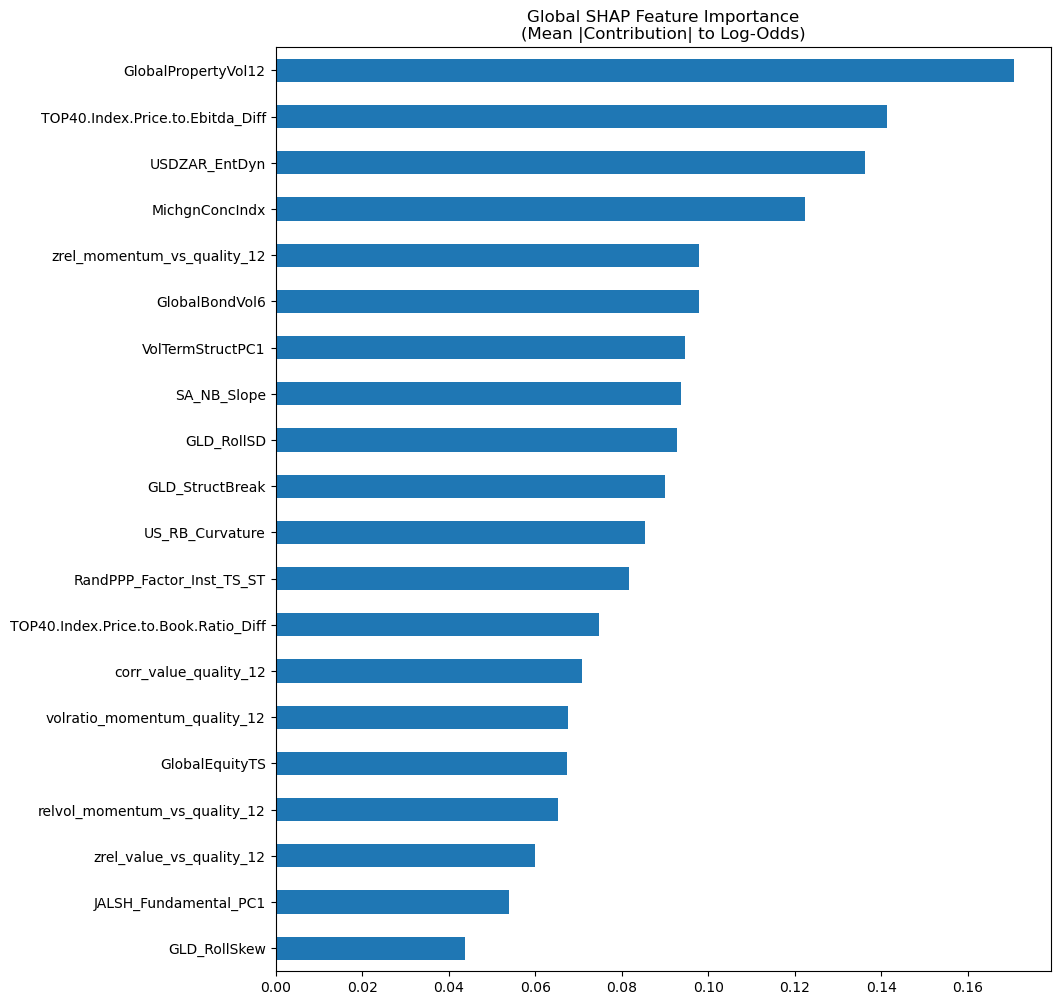

In [36]:
# ============================
# COEFFICIENT + SHAP IMPORTANCE
# ============================

# Extract data & names
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values
feature_names = results["feature_names"]

# Scale exactly as in main()
X = np.nan_to_num(X, nan=np.nan, posinf=1e10, neginf=-1e10)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit model on the same training window before the final 156 test points
best_params = results["best_params"]
model = LogisticRegression(**best_params)
model.fit(X_scaled[:-FINAL_TEST_POINTS], y[:-FINAL_TEST_POINTS])

# -----------------------------
# 1. Coefficient Importance
# -----------------------------
betas = model.beta[1:]  # exclude intercept

importance_coeff = (
    pd.Series(np.abs(betas), index=feature_names)
    .sort_values(ascending=False)
)

print("\n=== Coefficient Magnitude Importance ===")
print(importance_coeff.head(20))


# -----------------------------
# PLOT COEFFICIENT IMPORTANCE
# -----------------------------
plt.figure(figsize=(10, 12))
importance_coeff.head(20).plot(kind='barh', color='steelblue')

plt.title("Coefficient Magnitude Feature Importance\n(Logistic Regression)")
plt.xlabel("Absolute Coefficient Value")
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()


# -----------------------------
# 2. SHAP Values (linear logistic)
# -----------------------------
X_used = X_scaled[:-FINAL_TEST_POINTS]

# shap contribution is x * beta
shap_values = X_used * betas

shap_df = pd.DataFrame(shap_values, columns=feature_names)

importance_shap = (
    shap_df.abs().mean().sort_values(ascending=False)
)

print("\n=== Global SHAP Importance (Mean |Contribution|) ===")
print(importance_shap.head(20))


# -----------------------------
# 3. Plot SHAP Global Importance
# -----------------------------
plt.figure(figsize=(10, 12))
importance_shap.head(20).plot(kind='barh')
plt.title("Global SHAP Feature Importance\n(Mean |Contribution| to Log-Odds)")
plt.gca().invert_yaxis()
plt.show()
